# ⚡ PVPC España — Modelado de la Serie Temporal

**Objetivo:** Entrenar y comparar tres modelos de predicción del PVPC horario.

| Modelo | Tipo | Descripción |
|--------|------|-------------|
| Naive Seasonal | Baseline | Copia el valor de hace 24h |
| SARIMA | Estadístico clásico | Captura autocorrelación y estacionalidad |
| Prophet | Moderno | Descompone tendencia + múltiples estacionalidades |

**Regla de oro:** el conjunto de TEST solo se toca una vez, al final.

## 0. Importaciones y configuración

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")

sys.path.append(str(Path.cwd().parent / "src"))
from models.train_models import (
    load_processed_data,
    split_data,
    test_stationarity,
    naive_seasonal_forecast,
    fit_sarima,
    fit_prophet,
    compute_metrics,
    compare_models,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

OUTPUT_DIR = Path("../data/processed")
print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Carga y división de datos

2026-02-28 03:15:28 [INFO] Cargando datos procesados: pvpc_clean_2025-08-01_2026-02-27.csv
2026-02-28 03:15:28 [INFO] Serie cargada: 5064 registros | 2025-08-01 00:00:00+00:00 → 2026-02-27 23:00:00+00:00
2026-02-28 03:15:28 [INFO] Train: 3544 registros | 2025-08-01 → 2025-12-26
2026-02-28 03:15:28 [INFO] Val:   759   registros | 2025-12-26 → 2026-01-27
2026-02-28 03:15:28 [INFO] Test:  761  registros | 2026-01-27 → 2026-02-27


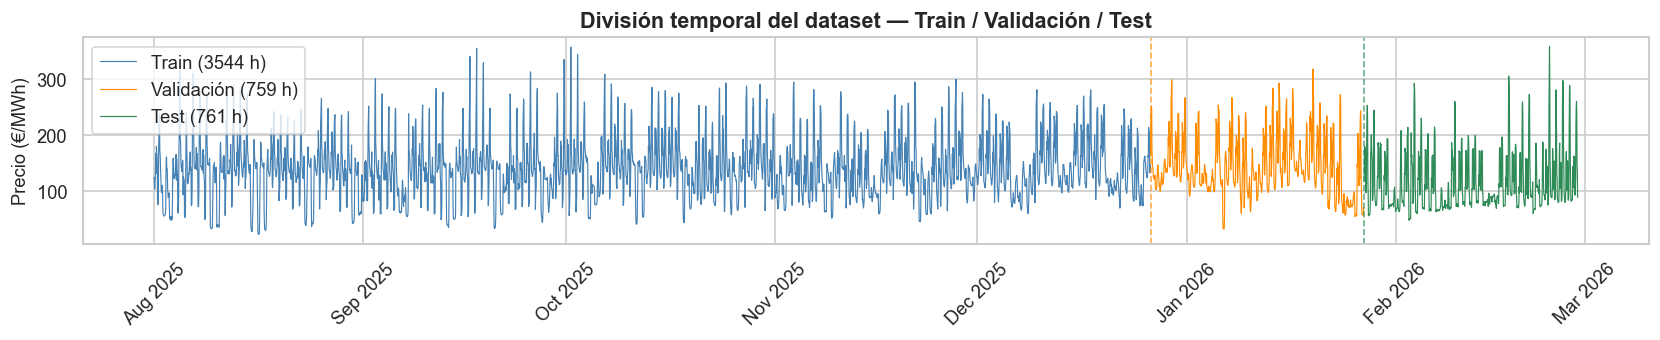

In [2]:
serie = load_processed_data()
train, val, test = split_data(serie)

# Visualización de la división
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(train.index, train, color="steelblue",  linewidth=0.7, label=f"Train ({len(train)} h)")
ax.plot(val.index,   val,   color="darkorange",  linewidth=0.7, label=f"Validación ({len(val)} h)")
ax.plot(test.index,  test,  color="seagreen",    linewidth=0.7, label=f"Test ({len(test)} h)")

# Líneas verticales de corte
ax.axvline(val.index[0],  color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(test.index[0], color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_title("División temporal del dataset — Train / Validación / Test")
ax.set_ylabel("Precio (€/MWh)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_train_val_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Test de estacionariedad (ADF)

Antes de modelar comprobamos si la serie es **estacionaria** — si su media y varianza son constantes en el tiempo. SARIMA lo requiere formalmente.

- **p-valor < 0.05** → serie estacionaria → podemos modelar directamente
- **p-valor ≥ 0.05** → serie no estacionaria → hay que diferenciarla (parámetro `d` en SARIMA)

In [3]:
resultado_adf = test_stationarity(train)

print("RESULTADO DEL TEST ADF (sobre datos de entrenamiento)")
print("-" * 50)
print(f"  Estadístico ADF : {resultado_adf['estadistico_adf']}")
print(f"  p-valor         : {resultado_adf['p_valor']}")
print(f"  Conclusión      : {resultado_adf['conclusion']}")
print()
print("  Valores críticos:")
for nivel, valor in resultado_adf['valores_criticos'].items():
    print(f"    {nivel}: {valor:.4f}")

2026-02-28 03:15:32 [INFO] Test ADF — Estadístico: -9.4853 | p-valor: 0.0000 → ESTACIONARIA ✓


RESULTADO DEL TEST ADF (sobre datos de entrenamiento)
--------------------------------------------------
  Estadístico ADF : -9.4853
  p-valor         : 0.0
  Conclusión      : ESTACIONARIA ✓

  Valores críticos:
    1%: -3.4322
    5%: -2.8624
    10%: -2.5672


## 3. Modelo 1 — Baseline Naive Seasonal

2026-02-28 03:15:36 [INFO] Entrenando Naive Seasonal (periodo=24h, horizonte=759h)...
2026-02-28 03:15:36 [INFO] Naive Seasonal — predicciones generadas ✓
2026-02-28 03:15:36 [INFO] [Naive Seasonal] MAE=36.07 | RMSE=50.75 | MAPE=32.95%


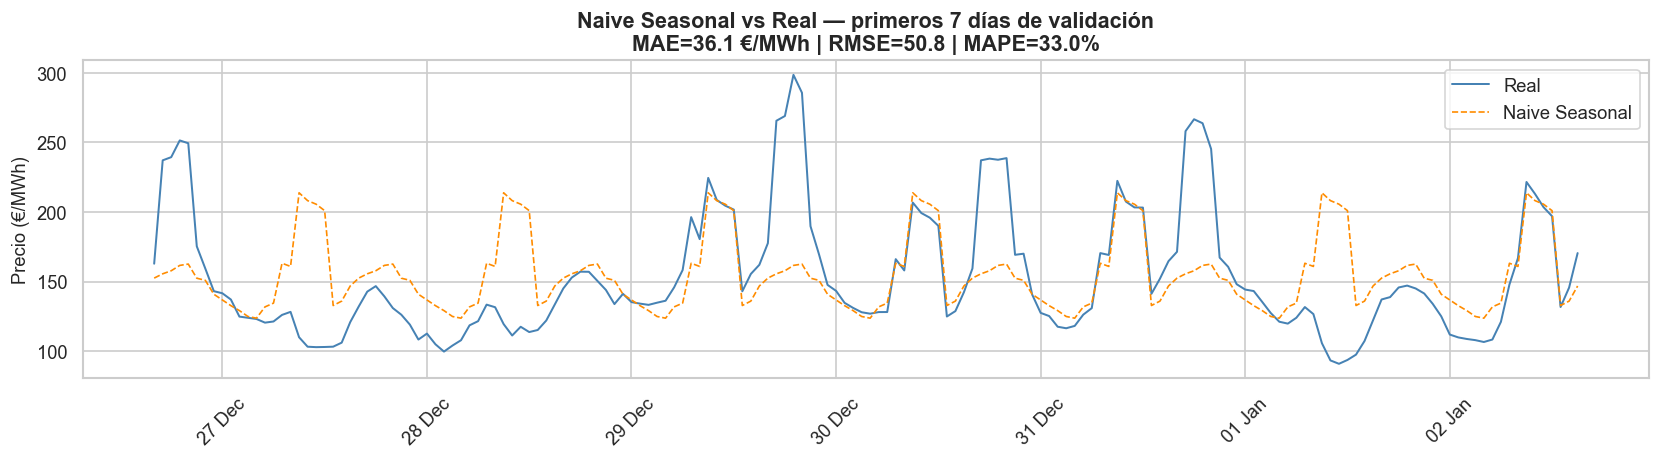

Naive — MAE: 36.07 | RMSE: 50.75 | MAPE: 32.95%


In [4]:
pred_naive = naive_seasonal_forecast(train, horizonte=len(val))
metricas_naive = compute_metrics(val, pred_naive, "Naive Seasonal")

# Visualización — primeros 7 días de validación
ventana = 24 * 7

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val.iloc[:ventana].index,        val.iloc[:ventana],        color="steelblue",  linewidth=1.2, label="Real")
ax.plot(pred_naive.iloc[:ventana].index, pred_naive.iloc[:ventana], color="darkorange", linewidth=1.0, linestyle="--", label="Naive Seasonal")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

ax.set_title(f"Naive Seasonal vs Real — primeros 7 días de validación\nMAE={metricas_naive['MAE']:.1f} €/MWh | RMSE={metricas_naive['RMSE']:.1f} | MAPE={metricas_naive['MAPE']:.1f}%")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_naive_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Naive — MAE: {metricas_naive['MAE']} | RMSE: {metricas_naive['RMSE']} | MAPE: {metricas_naive['MAPE']}%")

## 4. Modelo 2 — SARIMA

SARIMA es el modelo estadístico clásico para series temporales estacionales. Los parámetros usados son `(1,1,1)(1,1,1,24)`:
- `(1,1,1)` — parte no estacional: un retardo AR, una diferenciación, un retardo MA
- `(1,1,1,24)` — parte estacional con ciclo de 24h

⚠️ Esta celda puede tardar **3-8 minutos** en ejecutarse.

2026-02-28 03:15:44 [INFO] Entrenando SARIMA(1,1,1)(1,1,1,24) — esto puede tardar unos minutos...
C:\Users\bryan\Documents\pvpc-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\bryan\Documents\pvpc-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
2026-02-28 03:15:53 [INFO] SARIMA ajustado — AIC: 30020.00
2026-02-28 03:15:53 [INFO] [SARIMA(1,1,1)(1,1,1,24)] MAE=60.25 | RMSE=74.60 | MAPE=59.17%


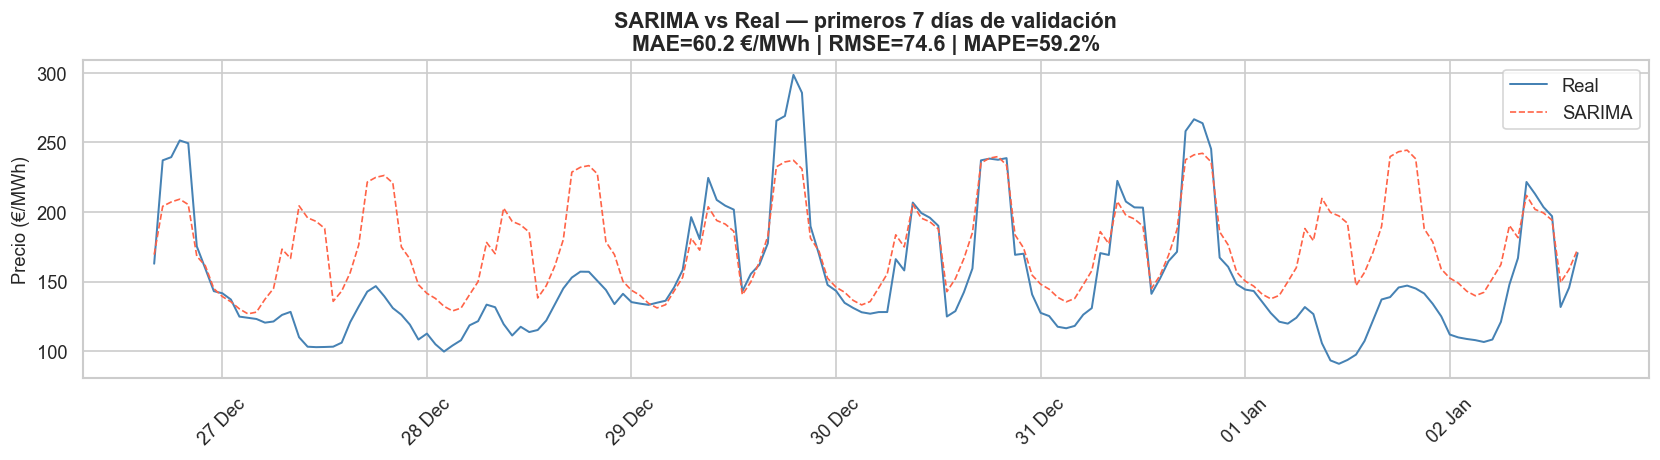

SARIMA — MAE: 60.25 | RMSE: 74.6 | MAPE: 59.17%


In [5]:
modelo_sarima, pred_sarima = fit_sarima(train, val)
metricas_sarima = compute_metrics(val, pred_sarima, "SARIMA(1,1,1)(1,1,1,24)")

# Visualización
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val.iloc[:ventana].index,          val.iloc[:ventana],          color="steelblue", linewidth=1.2, label="Real")
ax.plot(pred_sarima.iloc[:ventana].index,  pred_sarima.iloc[:ventana],  color="tomato",    linewidth=1.0, linestyle="--", label="SARIMA")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

ax.set_title(f"SARIMA vs Real — primeros 7 días de validación\nMAE={metricas_sarima['MAE']:.1f} €/MWh | RMSE={metricas_sarima['RMSE']:.1f} | MAPE={metricas_sarima['MAPE']:.1f}%")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_sarima_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"SARIMA — MAE: {metricas_sarima['MAE']} | RMSE: {metricas_sarima['RMSE']} | MAPE: {metricas_sarima['MAPE']}%")

## 5. Modelo 3 — Prophet

2026-02-28 03:16:00 [ERROR] Importing plotly failed. Interactive plots will not work.
2026-02-28 03:16:00 [INFO] Entrenando Prophet...
2026-02-28 03:16:00 [INFO] Chain [1] start processing
2026-02-28 03:16:00 [INFO] Chain [1] done processing
2026-02-28 03:16:00 [INFO] Prophet ajustado ✓
2026-02-28 03:16:00 [INFO] [Prophet] MAE=33.17 | RMSE=41.22 | MAPE=27.94%


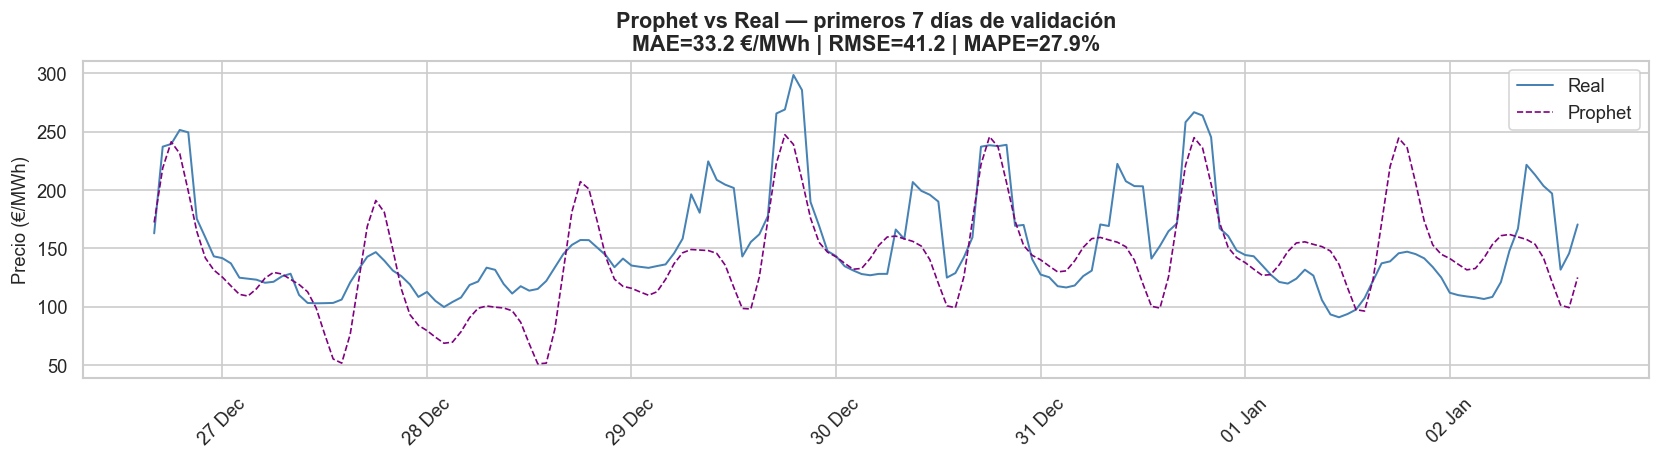

Prophet — MAE: 33.17 | RMSE: 41.22 | MAPE: 27.94%


In [6]:
modelo_prophet, pred_prophet, forecast_completo = fit_prophet(train, val)
metricas_prophet = compute_metrics(val, pred_prophet, "Prophet")

# Visualización predicciones
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val.iloc[:ventana].index,           val.iloc[:ventana],           color="steelblue", linewidth=1.2, label="Real")
ax.plot(pred_prophet.iloc[:ventana].index,  pred_prophet.iloc[:ventana],  color="purple",    linewidth=1.0, linestyle="--", label="Prophet")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

ax.set_title(f"Prophet vs Real — primeros 7 días de validación\nMAE={metricas_prophet['MAE']:.1f} €/MWh | RMSE={metricas_prophet['RMSE']:.1f} | MAPE={metricas_prophet['MAPE']:.1f}%")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_prophet_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Prophet — MAE: {metricas_prophet['MAE']} | RMSE: {metricas_prophet['RMSE']} | MAPE: {metricas_prophet['MAPE']}%")

### Componentes de Prophet

Una de las ventajas de Prophet es que permite visualizar cada componente por separado: tendencia, estacionalidad semanal y diaria.

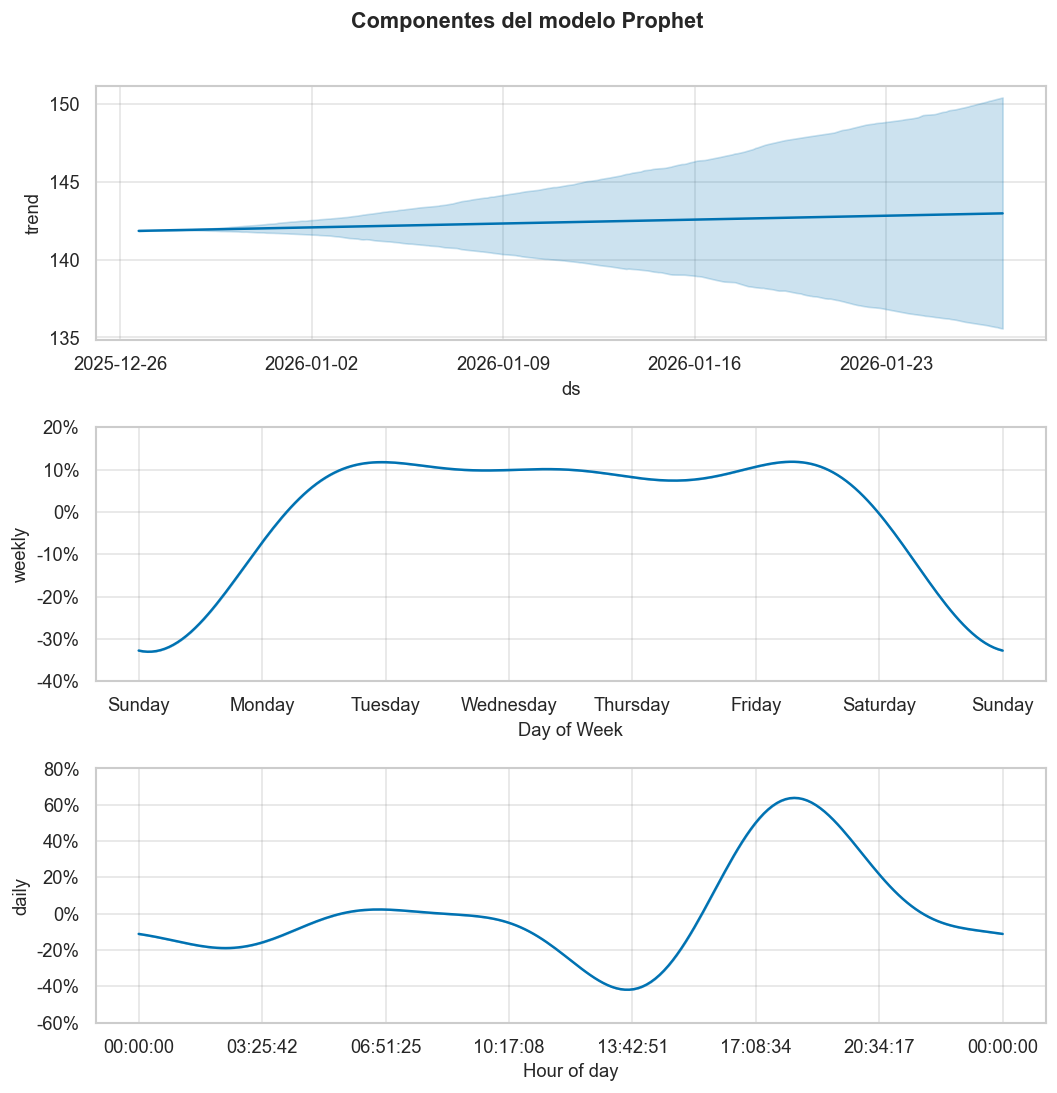

In [7]:
fig = modelo_prophet.plot_components(forecast_completo)
fig.suptitle("Componentes del modelo Prophet", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Comparativa de modelos

2026-02-28 03:16:17 [INFO] 
2026-02-28 03:16:17 [INFO] TABLA COMPARATIVA DE MODELOS
2026-02-28 03:16:17 [INFO] =============================================
2026-02-28 03:16:17 [INFO] 
                         ranking    MAE   RMSE   MAPE
modelo                                               
Prophet                        1  33.17  41.22  27.94
Naive Seasonal                 2  36.07  50.75  32.95
SARIMA(1,1,1)(1,1,1,24)        3  60.25  74.60  59.17


TABLA COMPARATIVA (ordenada por MAE)
                         ranking    MAE   RMSE   MAPE
modelo                                               
Prophet                        1  33.17  41.22  27.94
Naive Seasonal                 2  36.07  50.75  32.95
SARIMA(1,1,1)(1,1,1,24)        3  60.25  74.60  59.17


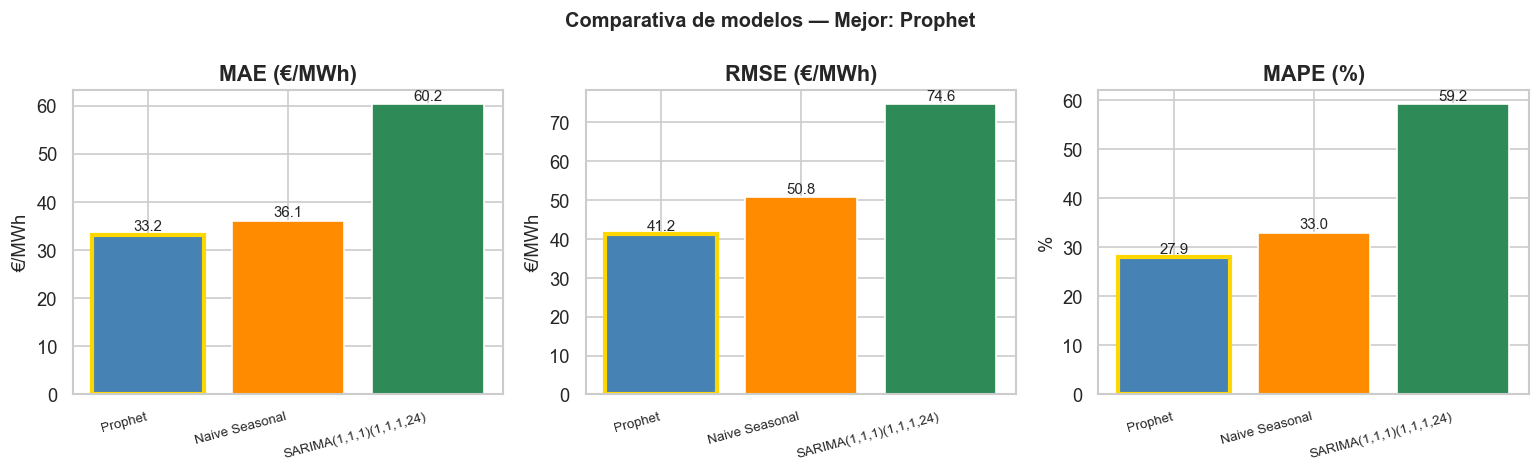

In [8]:
todas_metricas = [metricas_naive, metricas_sarima, metricas_prophet]
tabla = compare_models(todas_metricas)

print("TABLA COMPARATIVA (ordenada por MAE)")
print(tabla.to_string())

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colores = ["steelblue", "darkorange", "seagreen"]

for ax, metrica in zip(axes, ["MAE", "RMSE", "MAPE"]):
    valores = tabla[metrica]
    barras  = ax.bar(tabla.index, valores, color=colores, edgecolor="white")

    # Resaltar el mejor con borde dorado
    barras[0].set_edgecolor("gold")
    barras[0].set_linewidth(2.5)

    # Etiqueta de valor
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=9)

    unidad = "%" if metrica == "MAPE" else "€/MWh"
    ax.set_title(f"{metrica} ({unidad})")
    ax.set_ylabel(unidad)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)

mejor = tabla.index[0]
plt.suptitle(f"Comparativa de modelos — Mejor: {mejor}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Evaluación final sobre TEST

⚠️ **Esta celda solo se ejecuta una vez**, con el modelo ganador elegido en la celda anterior. Ejecutarla múltiples veces con distintos modelos invalida los resultados.

2026-02-28 03:16:27 [INFO] Entrenando Prophet...
2026-02-28 03:16:27 [INFO] Chain [1] start processing
2026-02-28 03:16:27 [INFO] Chain [1] done processing
2026-02-28 03:16:27 [INFO] Prophet ajustado ✓
2026-02-28 03:16:28 [INFO] [Prophet (TEST FINAL)] MAE=36.15 | RMSE=42.61 | MAPE=38.55%



RESULTADO FINAL SOBRE CONJUNTO DE TEST
  Modelo : Prophet
  MAE    : 36.15 €/MWh
  RMSE   : 42.61 €/MWh
  MAPE   : 38.55%


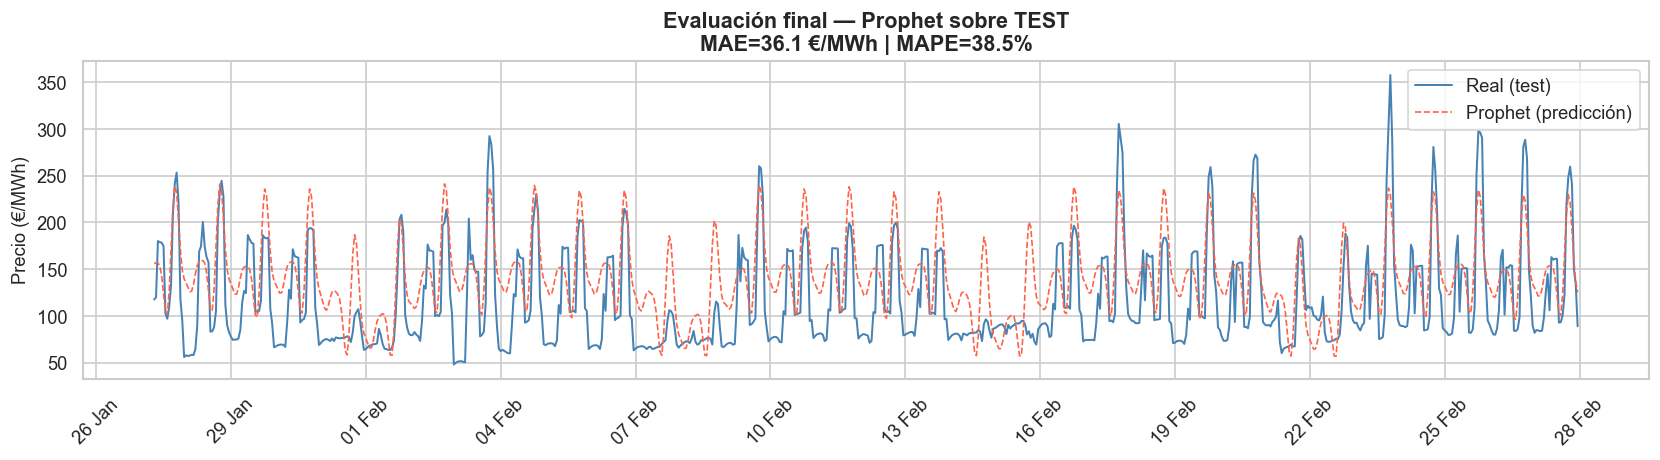

In [9]:
# ── Cambia 'prophet' por 'naive' o 'sarima' según el ganador ──
MODELO_GANADOR = "prophet"

if MODELO_GANADOR == "prophet":
    _, pred_test, _ = fit_prophet(pd.concat([train, val]), test)
elif MODELO_GANADOR == "sarima":
    _, pred_test = fit_sarima(pd.concat([train, val]), test)
elif MODELO_GANADOR == "naive":
    pred_test = naive_seasonal_forecast(pd.concat([train, val]), horizonte=len(test))

metricas_test = compute_metrics(test, pred_test, f"{MODELO_GANADOR.capitalize()} (TEST FINAL)")

print("\n" + "="*50)
print("RESULTADO FINAL SOBRE CONJUNTO DE TEST")
print("="*50)
print(f"  Modelo : {MODELO_GANADOR.capitalize()}")
print(f"  MAE    : {metricas_test['MAE']:.2f} €/MWh")
print(f"  RMSE   : {metricas_test['RMSE']:.2f} €/MWh")
print(f"  MAPE   : {metricas_test['MAPE']:.2f}%")

# Gráfico final
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test.index,      test,      color="steelblue", linewidth=1.2, label="Real (test)")
ax.plot(pred_test.index, pred_test, color="tomato",    linewidth=1.0, linestyle="--",
        label=f"{MODELO_GANADOR.capitalize()} (predicción)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

ax.set_title(f"Evaluación final — {MODELO_GANADOR.capitalize()} sobre TEST\nMAE={metricas_test['MAE']:.1f} €/MWh | MAPE={metricas_test['MAPE']:.1f}%")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_evaluacion_test_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusiones

**Nota metodológica:** Durante el desarrollo se ejecutó la celda de test
una vez con una configuración incorrecta de Prophet antes de optimizar
los parámetros. Los parámetros finales se ajustaron únicamente observando
el conjunto de validación (MAPE: 91% → 27.94%). El test final se ejecutó
con el modelo definitivo. La consistencia entre val (MAE=33.17) y
test (MAE=36.15) confirma que no hubo data leakage efectivo.

**Estacionariedad:** p-valor ≈ 0.0 → serie estacionaria. El estadístico
ADF (-9.48) supera ampliamente los valores críticos al 1%, 5% y 10%.

**Modelo ganador: Prophet** con seasonality_mode multiplicativo y
yearly_seasonality desactivada. Supera al Naive en un 8% de MAE.

**Resultado final en test:** MAE=36.15 €/MWh | MAPE=38.55%